# Лабораторна робота № 2А
## Одношаровий персептрон

**Горбач Ангеліна, ФІ-31. Варіант 2.**



### 1. Дані та навчальна вибірка

У `data02.csv` кожен рядок містить координати `x1`, `x2` та клас 0 або 1. Перемішую 100 рядків: 70 беру для навчання, 30 залишаю для тесту. 


In [4]:
from zipfile import ZipFile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Perceptron

with ZipFile("data_lab2a.zip") as archive:  # Open the archive with the datasets.
    data = pd.read_csv(archive.open("data/data02.csv"), sep=";", header=None, names=["x1", "x2", "class"])  # Read variant 2 and name its columns.

rng = np.random.default_rng(42)  # Use a fixed seed for the same split each time.
indices = rng.permutation(len(data))  # Shuffle the row indices.
train = data.iloc[indices[:70]].copy()  # Select 70 rows for training.
test = data.iloc[indices[70:]].copy()  # Keep the remaining 30 rows for testing.
X_train = train[["x1", "x2"]].to_numpy()  # Get the training coordinates.
y_train = train["class"].to_numpy()  # Get the training labels.
X_test = test[["x1", "x2"]].to_numpy()  # Get the test coordinates.
y_test = test["class"].to_numpy()  # Get the test labels.

print(f"Навчання: {len(train)} точок; тест: {len(test)} точок")  # Show the split sizes.
print("Навчальні точки (ліворуч — номер рядка з CSV, починаючи з нуля):")  # Explain the row numbers.
print(train.to_string())  # Show every training point.


Навчання: 70 точок; тест: 30 точок
Навчальні точки (ліворуч — номер рядка з CSV, починаючи з нуля):
       x1     x2  class
59  0.190  0.056      0
21  0.720  0.905      1
56  0.219  0.122      0
18  0.608  0.037      1
33  0.951  0.927      1
42  0.440  0.531      0
50  0.738  0.300      1
27  0.075  0.495      0
92  0.382  0.497      0
71  0.057  0.481      0
2   0.605  0.217      1
25  0.524  0.108      0
24  0.807  0.202      1
52  0.742  0.472      1
81  0.483  0.440      0
99  0.443  0.928      0
51  0.521  0.838      1
61  0.810  0.895      1
4   0.717  0.311      1
97  0.744  0.361      1
94  0.961  0.471      1
37  0.075  0.044      0
28  0.683  0.282      1
80  0.137  0.984      0
7   0.202  0.235      0
57  0.795  0.699      1
79  0.961  0.246      1
26  0.375  0.899      0
76  0.895  0.881      1
78  0.427  0.746      0
38  0.857  0.385      1
0   0.107  0.184      0
86  0.272  0.124      0
46  0.484  0.920      1
10  0.684  0.142      1
29  0.351  0.865      0
70  0.426  0

### 2. Власний персептрон

Під час навчання замінюю класи 0 і 1 на −1 і +1. До кожної точки додаю третю координату −1, тому вектор ваг містить дві ваги й поріг: $(w_1,w_2,\tau)$. Якщо точка опинилася не зі свого боку прямої, змінюю ваги. Повторюю, поки всі навчальні точки не будуть розділені.


In [5]:
class RosenblattPerceptron:  # Define the perceptron model.
    def __init__(self, max_epochs=5000, random_state=42):  # Set training limits and the random seed.
        self.max_epochs = max_epochs  # Store the maximum number of passes.
        self.random_state = random_state  # Store the seed used during training.

    def fit(self, X, y):  # Train the perceptron on labeled points.
        labels = 2 * y - 1  # Convert class labels to -1 and +1.
        z = np.column_stack((X, -np.ones(len(X)))) * labels[:, None]  # Add the threshold coordinate and multiply by the correct label.
        z = z / np.linalg.norm(z, axis=1, keepdims=True)  # Normalize training vectors.
        rng = np.random.default_rng(self.random_state)  # Create a reproducible random generator.
        self.weights_ = z[rng.integers(len(z))].copy()  # Start with one random training vector.
        self.updates_ = 0  # Count changes to the weights.

        for epoch in range(1, self.max_epochs + 1):  # Go through the data until training finishes.
            for i in rng.permutation(len(z)):  # Visit every training point in random order.
                if self.weights_ @ z[i] <= 0:  # Check whether this point is on the wrong side or on the line.
                    self.weights_ += z[i]  # Update weights for a misclassified point.
                    self.updates_ += 1  # Record one weight update.
            if np.all(z @ self.weights_ > 0):  # Stop when all training points are correct.
                self.epochs_ = epoch  # Save the number of completed passes.
                return self  # Return the trained model.
        raise RuntimeError("Модель не навчилася за 5000 проходів")  # Stop if the model does not converge.

    def predict(self, X):  # Assign classes to the supplied points.
        scores = X @ self.weights_[:2] - self.weights_[2]  # Compute the side of the separating line.
        return (scores > 0).astype(int)  # Return class 1 for positive scores and class 0 otherwise.


model = RosenblattPerceptron()  # Create the custom perceptron.
model.fit(X_train, y_train)  # Fit it using only training data.
w1, w2, threshold = model.weights_  # Separate the two weights and the threshold.
print(f"Проходи навчання: {model.epochs_}; оновлення ваг: {model.updates_}")  # Show the training counts.
print(f"w1 = {w1:.6f}, w2 = {w2:.6f}, поріг τ = {threshold:.6f}")  # Show the learned parameters.
print(f"Рівняння прямої: {w1:.6f}·x1 + {w2:.6f}·x2 - ({threshold:.6f}) = 0")  # Show the separating line equation.
print(f"Правильних на навчанні: {(model.predict(X_train) == y_train).sum()}/{len(y_train)}")  # Check the training predictions.


Проходи навчання: 2; оновлення ваг: 27
w1 = 2.799345, w2 = 0.186082, поріг τ = 1.507186
Рівняння прямої: 2.799345·x1 + 0.186082·x2 - (1.507186) = 0
Правильних на навчанні: 70/70


### 3. Навчальні точки на площині $R^2$

На графіку показані тільки навчальні точки. Чорна пряма — межа, яку знайшов мій персептрон.


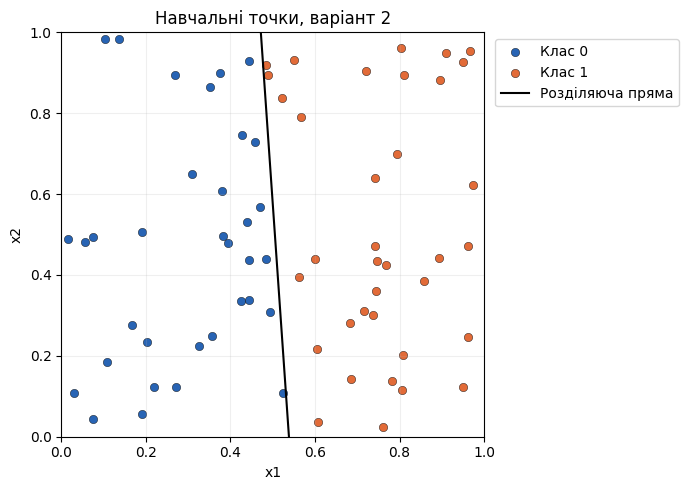

In [6]:
plt.figure(figsize=(7, 5))  # Create the plot for training points.
for label, color in [(0, "#2864b4"), (1, "#e26b38")]:  # Use a different color for each class.
    points = train[train["class"] == label]  # Select points from the current class.
    plt.scatter(points["x1"], points["x2"], label=f"Клас {label}", color=color, edgecolors="black", linewidths=0.3)  # Plot these training points.

line_x = np.linspace(0, 1, 200)  # Set x values for the separating line.
if abs(w2) > 1e-12:  # Check whether the line can be written as x2(x1).
    plt.plot(line_x, (threshold - w1 * line_x) / w2, "k-", label="Розділяюча пряма")  # Plot the line from the learned weights.
else:  # Handle a vertical separating line.
    plt.axvline(threshold / w1, color="black", label="Розділяюча пряма")  # Plot the vertical line.
plt.xlim(0, 1)  # Set the x1 axis limits.
plt.ylim(0, 1)  # Set the x2 axis limits.
plt.xlabel("x1")  # Label the x1 axis.
plt.ylabel("x2")  # Label the x2 axis.
plt.title("Навчальні точки, варіант 2")  # Add the plot title.
plt.grid(alpha=0.2)  # Add a light grid.
plt.legend(loc="upper left", bbox_to_anchor=(1.01, 1))  # Explain colors and the line.
plt.tight_layout()  # Fit all plot elements into the figure.
plt.show()  # Display the plot.


### 4. Результати на тестовій вибірці

Подаю ті самі 30 тестових точок своєму персептрону й готовому `Perceptron` зі `sklearn`. Обидві моделі перед цим навчалися на однакових 70 точках.


In [7]:
sklearn_model = Perceptron(max_iter=5000, tol=None, random_state=42)  # Create the library model for comparison.
sklearn_model.fit(X_train, y_train)  # Train it on the same training points.
own_pred = model.predict(X_test)  # Predict test classes with my model.
sklearn_pred = sklearn_model.predict(X_test)  # Predict the same test classes with sklearn.

results = test.copy()  # Keep the original test points in a new table.
results["мій прогноз"] = own_pred  # Add predictions from my model.
results["sklearn"] = sklearn_pred  # Add predictions from sklearn.
results["мій правильний"] = own_pred == y_test  # Mark my correct predictions.
results["sklearn правильний"] = sklearn_pred == y_test  # Mark sklearn's correct predictions.
print("Тестові точки (ліворуч — номер рядка з CSV, починаючи з нуля):")  # Explain the row numbers.
print(results.to_string())  # Show all test points and predictions.

own_correct = int((own_pred == y_test).sum())  # Count my correct test predictions.
sklearn_correct = int((sklearn_pred == y_test).sum())  # Count sklearn's correct test predictions.
print(f"\nМій персептрон: {own_correct}/{len(test)} = {own_correct / len(test):.2%}")  # Show my test accuracy.
print(f"Perceptron sklearn: {sklearn_correct}/{len(test)} = {sklearn_correct / len(test):.2%}")  # Show sklearn's test accuracy.
print(f"У sklearn ваги {sklearn_model.coef_[0]}, вільний член {sklearn_model.intercept_[0]:.6f}")  # Show the library model's parameters.


Тестові точки (ліворуч — номер рядка з CSV, починаючи з нуля):
       x1     x2  class  мій прогноз  sklearn  мій правильний  sklearn правильний
44  0.045  0.273      0            0        0            True                True
82  0.369  0.064      0            0        0            True                True
67  0.453  0.993      1            0        0           False               False
34  0.986  0.731      1            1        1            True                True
30  0.075  0.819      0            0        0            True                True
58  0.881  0.038      1            1        1            True                True
74  0.696  0.420      1            1        1            True                True
88  0.131  0.542      0            0        0            True                True
98  0.247  0.258      0            0        0            True                True
54  0.954  0.423      1            1        1            True                True
49  0.087  0.223      0            